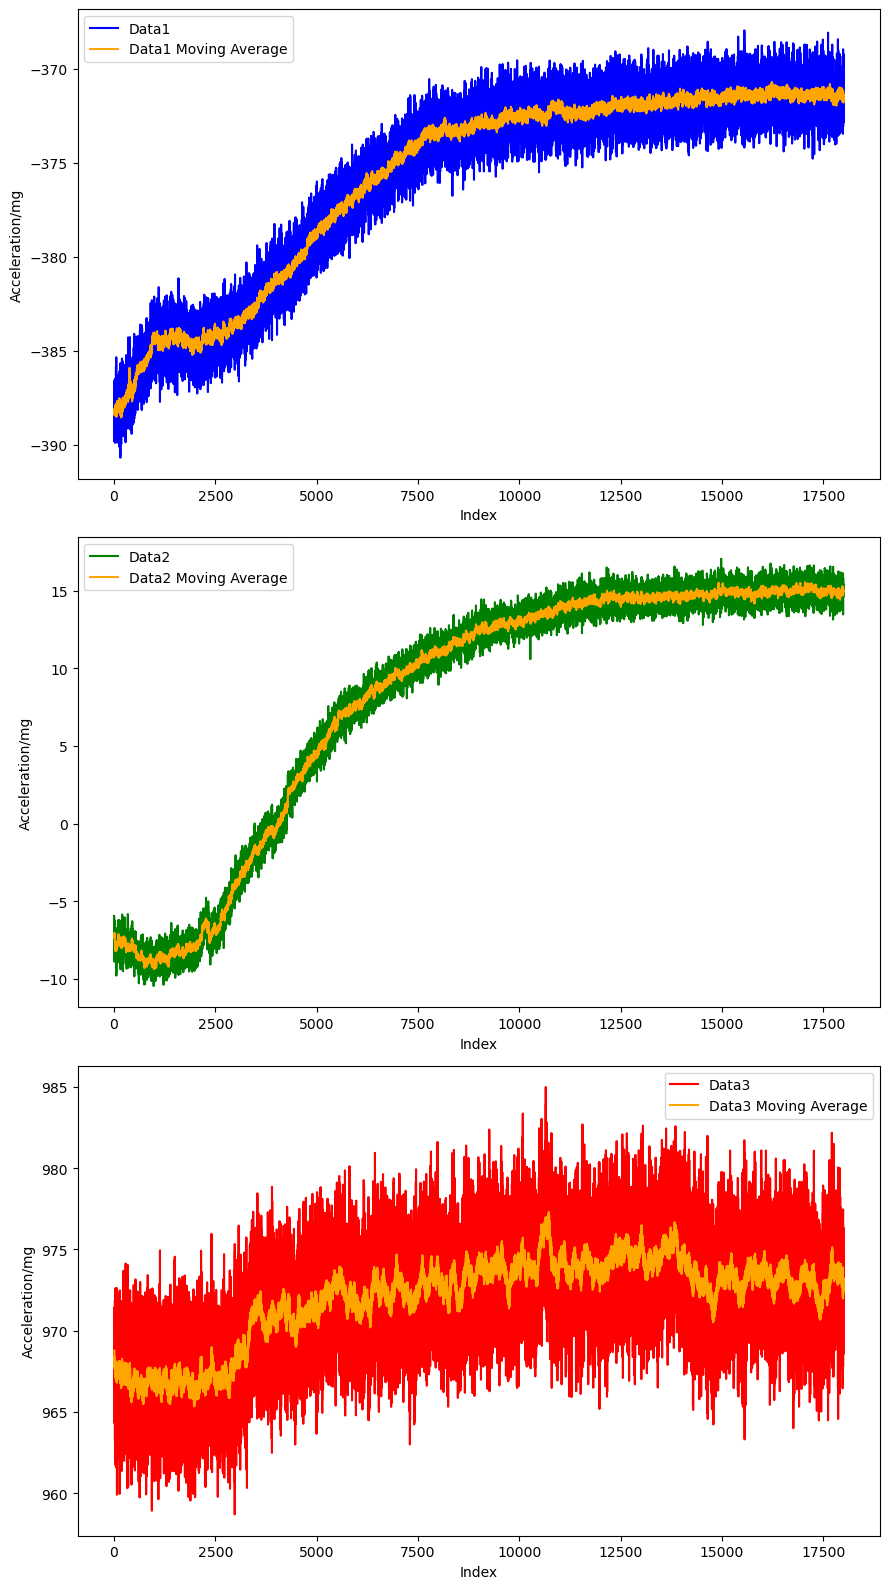

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# Path
datapath = '/Users/yuxiao/Xnode_collection_ Data/Environment/070201.txt'

# Read the contents
with open(datapath, 'r') as file:
    lines = file.readlines()

# Find the start of the data
data_start_idx = None
for i, line in enumerate(lines):
    if line.startswith('- start time synchronization'):
        data_start_idx = i + 1  # data parts
        break

if data_start_idx is None:
    raise ValueError("Failed to find start of data")

# Read the data part
data_lines = lines[data_start_idx:]
data = []

for line in data_lines:
    if line.strip():  # Skip empty lines
        parts = line.split(',')  # Use comma as delimiter
        if len(parts) == 5:  # Check if the line has 5 values
            try:
                data.append([int(parts[0]), int(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
            except ValueError:
                print(f"Skipping line due to ValueError: {line.strip()}")
                continue  # Skip lines with invalid data

# Convert to DataFrame
df = pd.DataFrame(data, columns=['Column1', 'Index', 'Data1', 'Data2', 'Data3'])

# Convert columns to numeric
df['Data1'] = pd.to_numeric(df['Data1'], errors='coerce')
df['Data2'] = pd.to_numeric(df['Data2'], errors='coerce')
df['Data3'] = pd.to_numeric(df['Data3'], errors='coerce')

# Check for NaN values
nan_rows = df[df[['Data1', 'Data2', 'Data3']].isna().any(axis=1)]
if not nan_rows.empty:
    print("Some rows contain NaN values:")
    print(nan_rows)

# Apply moving average window filter with a window size of 10 (for example)
window_size = 10
df['Data1_MA'] = df['Data1'].rolling(window=window_size).mean()
df['Data2_MA'] = df['Data2'].rolling(window=window_size).mean()
df['Data3_MA'] = df['Data3'].rolling(window=window_size).mean()

# Plot filtered Data1, Data2, Data3
plt.figure(figsize=(9, 16))

plt.subplot(3, 1, 1)
plt.plot(df['Index'], df['Data1'], color='blue', label='Data1')
plt.plot(df['Index'], df['Data1_MA'], color='orange', label='Data1 Moving Average')
plt.xlabel('Index')
plt.ylabel('Acceleration/mg')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['Index'], df['Data2'], color='green', label='Data2')
plt.plot(df['Index'], df['Data2_MA'], color='orange', label='Data2 Moving Average')
plt.xlabel('Index')
plt.ylabel('Acceleration/mg')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(df['Index'], df['Data3'], color='red', label='Data3')
plt.plot(df['Index'], df['Data3_MA'], color='orange', label='Data3 Moving Average')
plt.xlabel('Index')
plt.ylabel('Acceleration/mg')
plt.legend()

plt.tight_layout()
plt.savefig('moving_average_filtered.png')
plt.show()


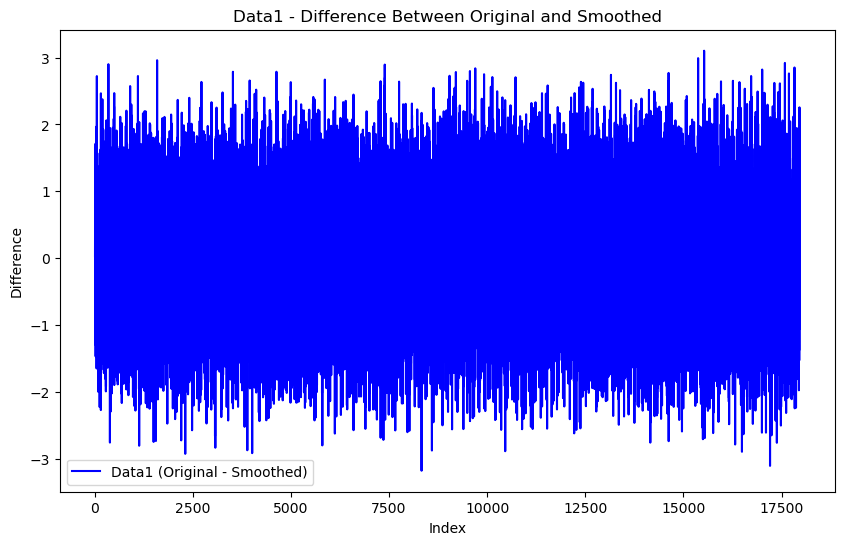

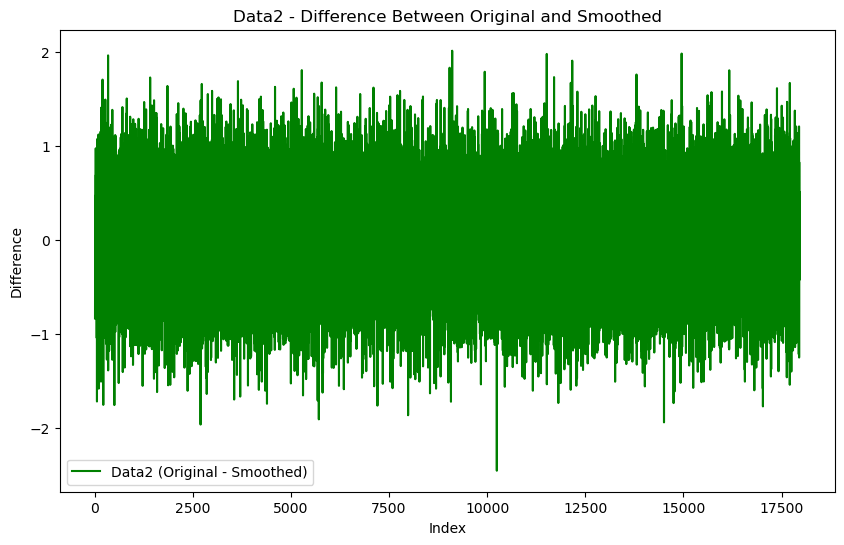

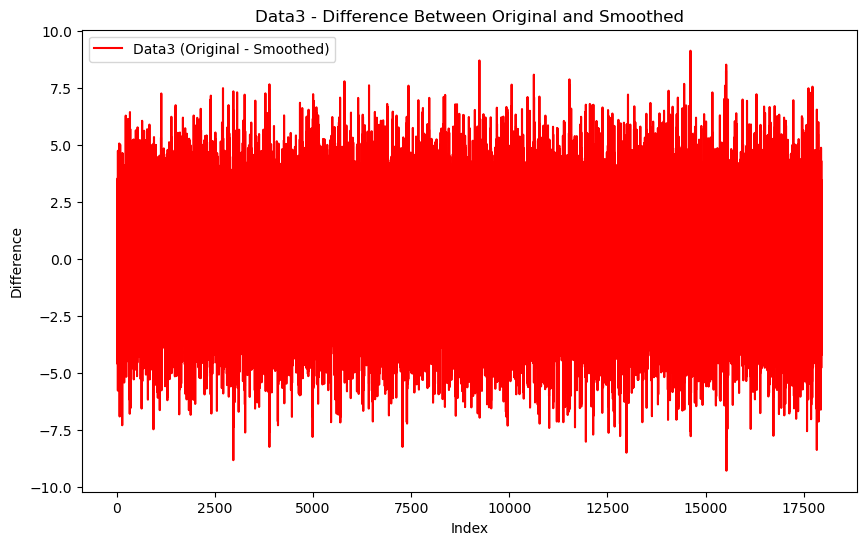

In [96]:
# Calculate the difference between original and smoothed data
data1_diff = df['Data1'] - df['Data1_MA']
data2_diff = df['Data2'] - df['Data2_MA']
data3_diff = df['Data3'] - df['Data3_MA']

# Plot Data1 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data1_diff, label='Data1 (Original - Smoothed)', color='blue')
plt.title('Data1 - Difference Between Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.legend()
# plt.grid(True)
plt.show()

# Plot Data2 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data2_diff, label='Data2 (Original - Smoothed)', color='green')
plt.title('Data2 - Difference Between Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.legend()
# plt.grid(True)
plt.show()

# Plot Data3 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data3_diff, label='Data3 (Original - Smoothed)', color='red')
plt.title('Data3 - Difference Between Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.legend()
# plt.grid(True)
plt.show()

In [97]:
# Calculate the average (mean) of Data1, Data2, and Data3
mean_data1 = df['Data1'].mean()
mean_data2 = df['Data2'].mean()
mean_data3 = df['Data3'].mean()
print(mean_data3)


971.9981385476668


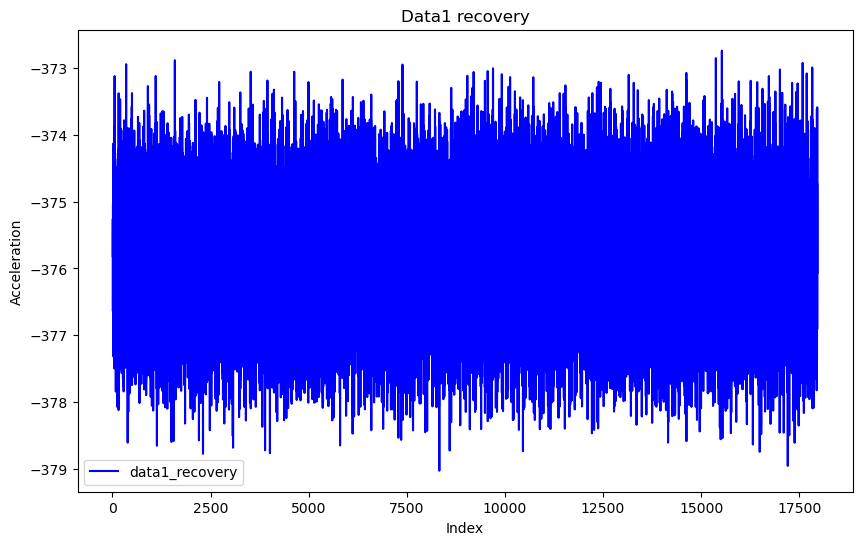

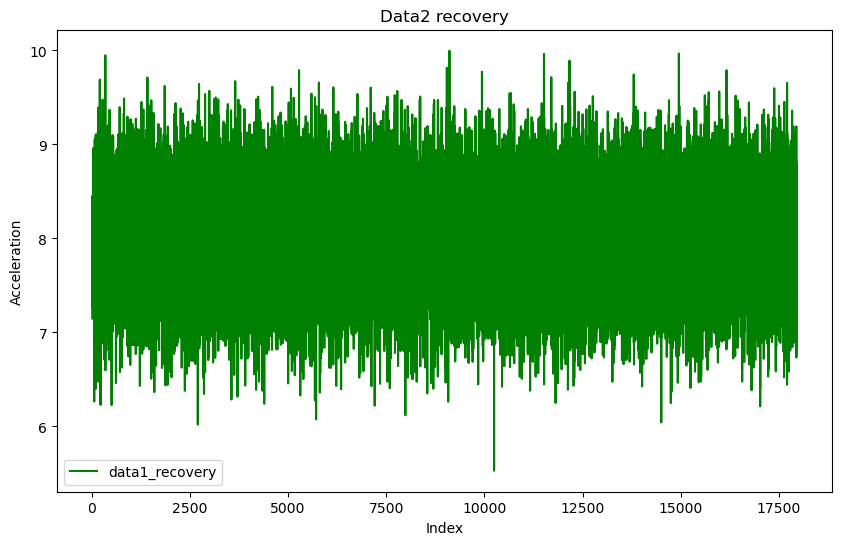

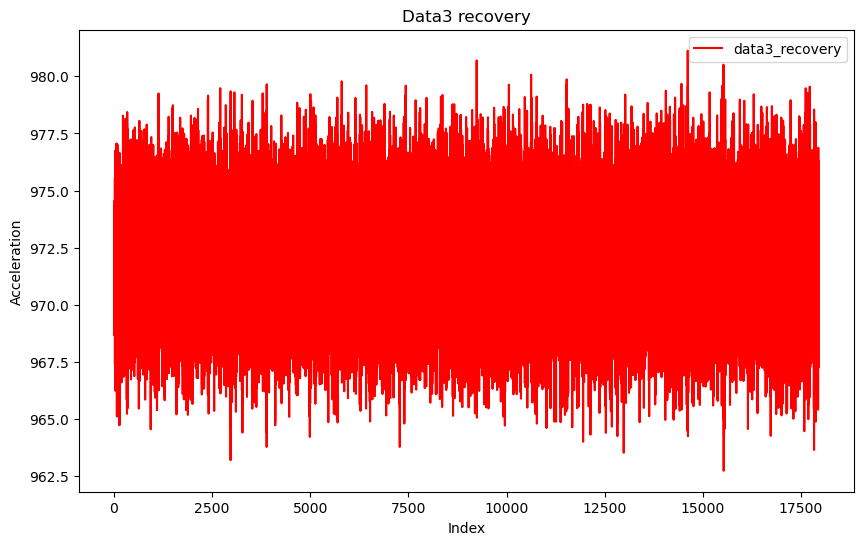

In [98]:
data1_recovery = data1_diff + mean_data1
data2_recovery = data2_diff + mean_data2
data3_recovery = data3_diff + mean_data3

# Plot Data1 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data1_recovery, label='data1_recovery', color='blue')
plt.title('Data1 recovery')
plt.xlabel('Index')
plt.ylabel('Acceleration')
plt.legend()
# plt.grid(True)
plt.show()

# Plot Data2 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data2_recovery, label='data1_recovery', color='green')
plt.title('Data2 recovery')
plt.xlabel('Index')
plt.ylabel('Acceleration')
plt.legend()
# plt.grid(True)
plt.show()

# Plot Data3 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data3_recovery, label='data3_recovery', color='red')
plt.title('Data3 recovery')
plt.xlabel('Index')
plt.ylabel('Acceleration')
plt.legend()
# plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


float64
0    968.796448
1    969.611755
2    969.139160
3    969.252625
4    969.493774
Name: Data3, dtype: float64


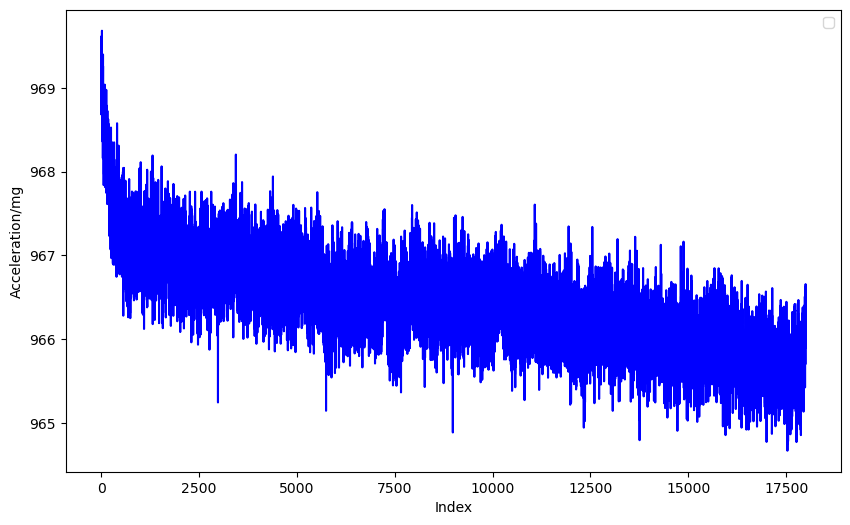

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Path
datapath = '/Users/yuxiao/Xnode_collection_ Data/Environment/070304.txt'

# read complete contents
with open(datapath, 'r') as file:
    lines = file.readlines()

# start index of data
data_start_idx = None
for i, line in enumerate(lines):
    if line.startswith('- start time synchronization'):
        data_start_idx = i + 1  # data parts
        break

# check if find data start idx
if data_start_idx is None:
    raise ValueError("fail to find start of data")

# read data part
data_lines = lines[data_start_idx:]
data = []

for line in data_lines:
    if line.strip():  # skip vacumn line
        parts = line.split(',')  # 使用逗号分隔符
        if len(parts) == 5:  # check if number lines
            try:
                data.append([int(parts[0]), int(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
            except ValueError:
                print(f"Skipping line due to ValueError: {line.strip()}")
                continue  # skip NAN lines

# convert to DataFrame
df = pd.DataFrame(data, columns=['Column1', 'Index', 'Data1', 'Data2', 'Data3'])

# convert to number
df['Data3'] = pd.to_numeric(df['Data3'], errors='coerce')

# Check NAN
nan_rows = df[df['Data3'].isna()]
if not nan_rows.empty:
    print("value line can't convert to number")
    print(nan_rows)

# Check Data1 type and content
print(df['Data3'].dtype)
print(df['Data3'].head())

# Remove NAN
if df['Data3'].isna().sum() == 0:
    # Plot Data1 figure
    plt.figure(figsize=(10, 6))
    plt.plot(df['Index'], df['Data3'], color='blue')
    plt.xlabel('Index')
    plt.ylabel('Acceleration/mg')
    # plt.title('X axis')
    plt.legend()
    # plt.grid(True)
    plt.savefig('x.png')
    plt.show()
else:
    print("Data3 include value that can't convert to number")



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


float64
0   -389.809723
1   -388.077850
2   -388.009552
3   -387.250793
4   -389.382813
Name: Data1, dtype: float64


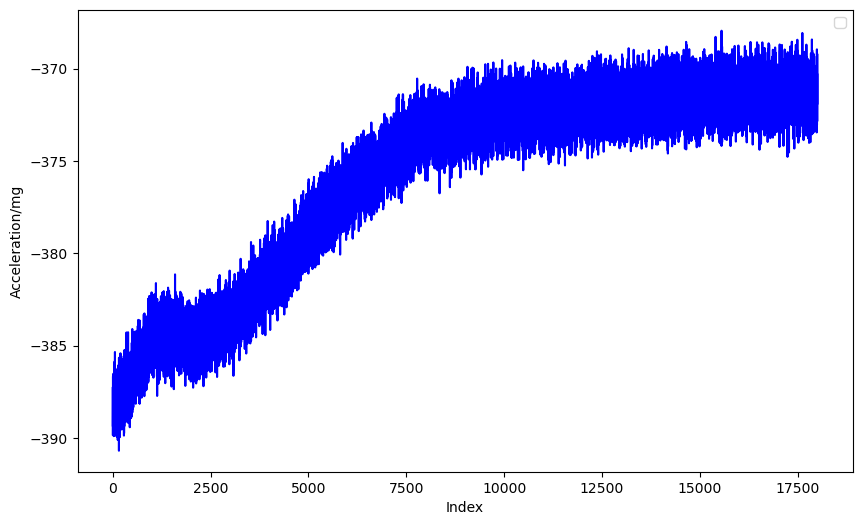

In [80]:
# Path
datapath = '/Users/yuxiao/Xnode_collection_ Data/Environment/070201.txt'

# read complete contents
with open(datapath, 'r') as file:
    lines = file.readlines()

# start index of data
data_start_idx = None
for i, line in enumerate(lines):
    if line.startswith('- start time synchronization'):
        data_start_idx = i + 1  # data parts
        break

# check if find data start idx
if data_start_idx is None:
    raise ValueError("fail to find start of data")

# read data part
data_lines = lines[data_start_idx:]
data = []

for line in data_lines:
    if line.strip():  # skip vacumn line
        parts = line.split(',')  # 使用逗号分隔符
        if len(parts) == 5:  # check if number lines
            try:
                data.append([int(parts[0]), int(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
            except ValueError:
                print(f"Skipping line due to ValueError: {line.strip()}")
                continue  # skip NAN lines

# convert to DataFrame
df = pd.DataFrame(data, columns=['Column1', 'Index', 'Data1', 'Data2', 'Data3'])

# convert to number
df['Data1'] = pd.to_numeric(df['Data1'], errors='coerce')

# Check NAN
nan_rows = df[df['Data1'].isna()]
if not nan_rows.empty:
    print("value line can't convert to number")
    print(nan_rows)

# Check Data1 type and content
print(df['Data1'].dtype)
print(df['Data1'].head())

# Remove NAN
if df['Data1'].isna().sum() == 0:
    # Plot Data1 figure
    plt.figure(figsize=(10, 6))
    plt.plot(df['Index'], df['Data1'], color='blue')
    plt.xlabel('Index')
    plt.ylabel('Acceleration/mg')
    # plt.title('X axis')
    plt.legend()
    # plt.grid(True)
    plt.savefig('x.png')
    plt.show()
else:
    print("Data1 include value that can't convert to number")



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


float64
0   -7.074465
1   -8.870741
2   -6.309926
3   -5.935992
4   -7.159399
Name: Data2, dtype: float64


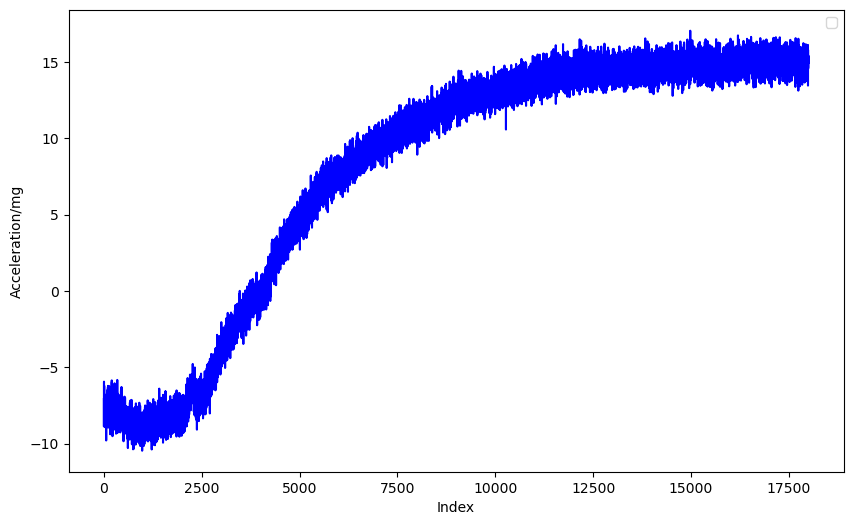

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Path
datapath = '/Users/yuxiao/Xnode_collection_ Data/Environment/070201.txt'

# read complete contents
with open(datapath, 'r') as file:
    lines = file.readlines()

# start index of data
data_start_idx = None
for i, line in enumerate(lines):
    if line.startswith('- start time synchronization'):
        data_start_idx = i + 1  # data parts
        break

# check if find data start idx
if data_start_idx is None:
    raise ValueError("fail to find start of data")

# read data part
data_lines = lines[data_start_idx:]
data = []

for line in data_lines:
    if line.strip():  # skip vacumn line
        parts = line.split(',')  # 使用逗号分隔符
        if len(parts) == 5:  # check if number lines
            try:
                data.append([int(parts[0]), int(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
            except ValueError:
                print(f"Skipping line due to ValueError: {line.strip()}")
                continue  # skip NAN lines

# convert to DataFrame
df = pd.DataFrame(data, columns=['Column1', 'Index', 'Data1', 'Data2', 'Data3'])

# convert to number
df['Data2'] = pd.to_numeric(df['Data2'], errors='coerce')

# Check NAN
nan_rows = df[df['Data2'].isna()]
if not nan_rows.empty:
    print("value line can't convert to number")
    print(nan_rows)

# Check Data1 type and content
print(df['Data2'].dtype)
print(df['Data2'].head())

# Remove NAN
if df['Data2'].isna().sum() == 0:
    # Plot Data1 figure
    plt.figure(figsize=(10, 6))
    plt.plot(df['Index'], df['Data2'], color='blue')
    plt.xlabel('Index')
    plt.ylabel('Acceleration/mg')
    # plt.title('X axis')
    plt.legend()
    # plt.grid(True)
    plt.savefig('x.png')
    plt.show()
else:
    print("Data2 include value that can't convert to number")

Optimal degree: 4, MSE: 1.4248478025432976


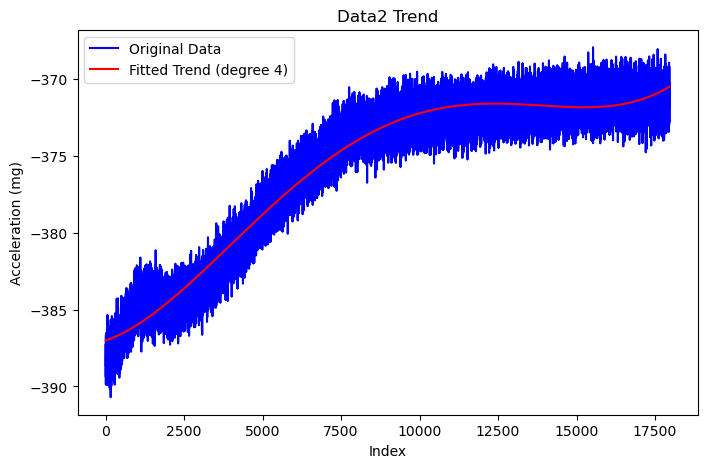

Optimal degree: 4, MSE: 9.204515173921369


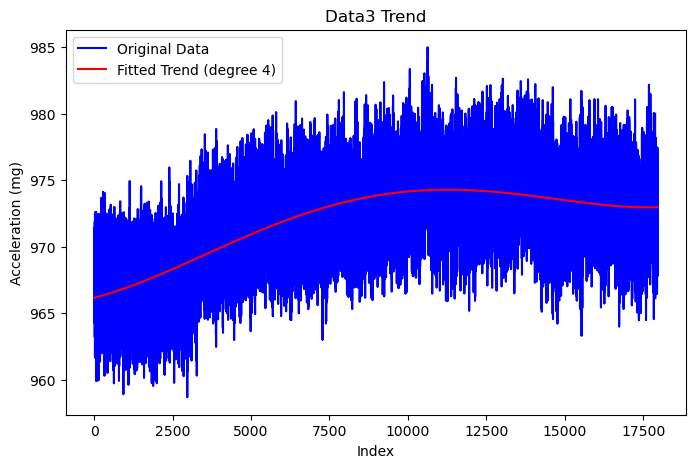

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from numpy.polynomial.polynomial import Polynomial
# 读取真实数据并确保长度相同
  # 设置 x 的长度与 y_data2 一致
y_data2 = df['Data1'] 
y_data3 = df['Data3'] 
x = np.linspace(0, len(y_data2)-1, num=len(y_data2))

# 确保 x 与 y 的长度相同
if len(x) != len(y_data2):
    x = np.linspace(0, len(y_data2)-1, num=len(y_data2))
if len(x) != len(y_data3):
    x = np.linspace(0, len(y_data3)-1, num=len(y_data3))

# 继续使用自适应多项式拟合
for y, title in zip([y_data2, y_data3], ["Data2 Trend", "Data3 Trend"]):
    poly_fit = adaptive_polynomial_fit(x, y)
    
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label='Original Data', color='blue')
    plt.plot(x, poly_fit(x), label=f'Fitted Trend (degree {poly_fit.order})', color='red')
    plt.xlabel('Index')
    plt.ylabel('Acceleration (mg)')
    plt.title(title)
    plt.legend()
    plt.show()


In [57]:


# # 自适应多项式拟合函数
# def adaptive_polynomial_fit(x, y, max_degree=4, error_threshold=1.0):
#     best_degree = 1
#     best_fit = None
#     best_error = float('inf')
    
#     # 尝试从低阶多项式开始拟合，逐步提升阶数
#     for degree in range(1, max_degree + 1):
#         # 拟合多项式
#         coeffs = np.polyfit(x, y, degree)
#         polynomial = np.poly1d(coeffs)
#         y_fit = polynomial(x)
        
#         # 计算均方误差
#         mse = mean_squared_error(y, y_fit)
        
#         # 检查误差并更新最佳拟合
#         if mse < error_threshold:
#             best_degree = degree
#             best_fit = polynomial
#             best_error = mse
#             break  # 满足误差标准，退出循环
#         elif mse < best_error:
#             best_degree = degree
#             best_fit = polynomial
#             best_error = mse

#     print(f"Optimal degree: {best_degree}, MSE: {best_error}")
#     return best_fit

# # 读取数据（以模拟数据为例）
# # 第二、第三张图的数据分别为 data2_x, data2_y 和 data3_x, data3_y
# # 用于拟合和绘图
# # x = np.linspace(0, 18000, num=18000)  # 替换为实际数据
# y_data2 = df['Data3'] 
# y_data3 = df['Data1'] 
# x = np.linspace(0, len(y_data2)-1, num=len(y_data2))
# # y_data2 = np.sin(x) + np.random.normal(scale=0.1, size=x.shape)  # 替换为第二张图数据
# # y_data3 = np.sin(x/2) + np.random.normal(scale=0.2, size=x.shape)  # 替换为第三张图数据

# # 对每组数据进行拟合并绘图
# for y, title in zip([y_data2, y_data3], ["Data2 Trend", "Data3 Trend"]):
#     poly_fit = adaptive_polynomial_fit(x, y)
    
#     # 绘制拟合曲线
#     plt.figure(figsize=(8, 5))
#     plt.plot(x, y, label='Original Data', color='blue')
#     plt.plot(x, poly_fit(x), label=f'Fitted Trend (degree {poly_fit.order})', color='red')
#     plt.xlabel('Index')
#     plt.ylabel('Acceleration (mg)')
#     plt.title(title)
#     plt.legend()
#     plt.show()


Optimal degree: 4, MSE: 1.4248478025432976


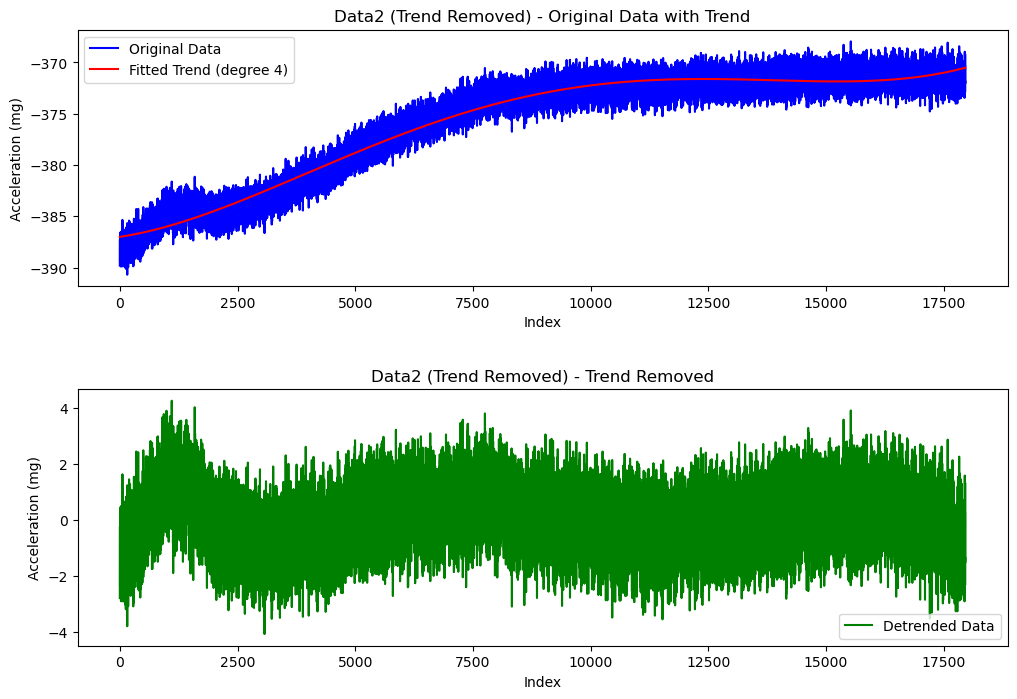

Optimal degree: 4, MSE: 9.204515173921369


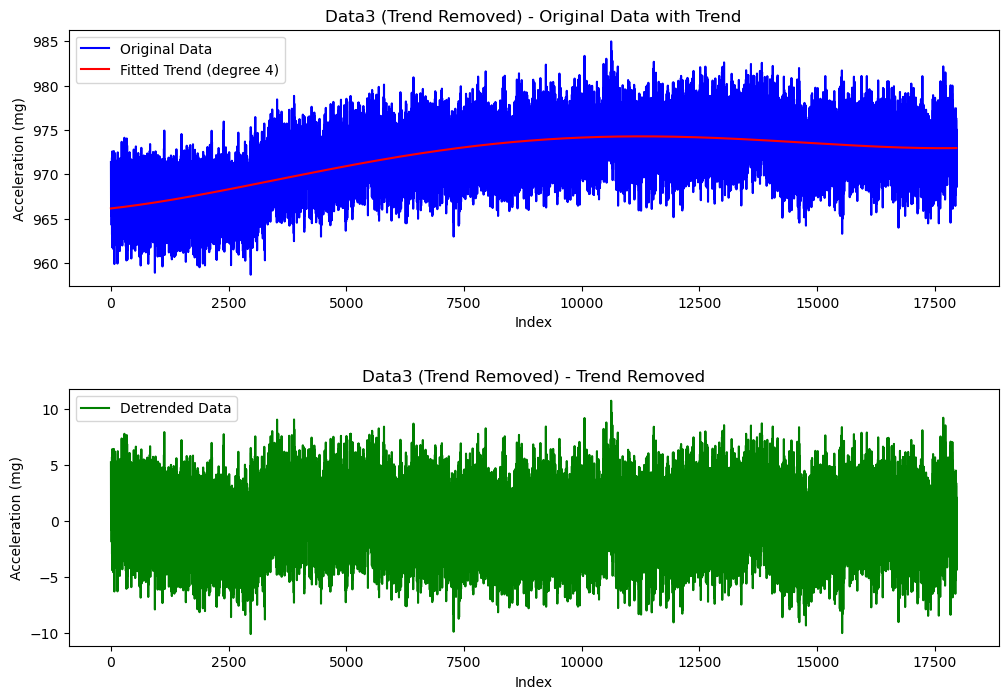

In [58]:
# 计算去除趋势后的数据并绘图
for y, title in zip([y_data2, y_data3], ["Data2 (Trend Removed)", "Data3 (Trend Removed)"]):
    # 拟合并计算趋势
    poly_fit = adaptive_polynomial_fit(x, y)
    trend = poly_fit(x)
    detrended_data = y - trend  # 去除趋势后的数据

    # 创建图形并调整大小
    plt.figure(figsize=(12, 8))
    
    # 原始数据和趋势线
    plt.subplot(2, 1, 1)
    plt.plot(x, y, label='Original Data', color='blue')
    plt.plot(x, trend, label=f'Fitted Trend (degree {poly_fit.order})', color='red')
    plt.xlabel('Index')
    plt.ylabel('Acceleration (mg)')
    plt.title(f'{title} - Original Data with Trend')
    plt.legend()
    
    # 去除趋势后的数据
    plt.subplot(2, 1, 2)
    plt.plot(x, detrended_data, label='Detrended Data', color='green')
    plt.xlabel('Index')
    plt.ylabel('Acceleration (mg)')
    plt.title(f'{title} - Trend Removed')
    plt.legend()
    
    # 调整布局，避免图形被截断
    plt.subplots_adjust(hspace=0.4)
    plt.show()
